Universidad del Valle de Guatemala  
Departamento de Ciencias de la Computación  
CC3085 - Inteligencia Artificial - sección 10  

Cristian Túnchez - 231359  
Nadissa Vela - 23764

# Laboratorio 10

## Task 2 - Depuración de un Sistema con Bug Deliberado

In [23]:
import numpy as np

CARRILES = 20
K = 10

def transicion(h_prev):
    # El vehiculo se mueve +1, 0 o -1 carril con igual probabilidad
    delta = np.random.choice([-1, 0, 1])
    return int(np.clip(h_prev + delta, 0, CARRILES - 1))
    
def emision(sensor, h):
    # Sensor reporta el carril real con prob 0.6, adyacente con 0.2, error con 0.2
    dist = abs(sensor - h)
    if dist == 0: return 0.6
    elif dist == 1: return 0.2
    else: return 0.2 / (CARRILES - 2)

def filtrado_particulas(observaciones):
    particulas = np.random.randint(0, CARRILES, K)
    for t, sensor in enumerate(observaciones):
        # PASO 1: Proponer
        propuestas = np.array([transicion(h) for h in particulas])
        # PASO 2: Ponderar
        pesos = np.array([emision(sensor, h) for h in propuestas])
        pesos_norm = pesos / pesos.sum()
        # PASO 3: Remuestrear <-- REVISEN ESTA LINEA
        idx = np.argsort(pesos_norm)[-K:]
        particulas = propuestas[idx]
        print(f"t={t+1} | sensor={sensor} | particulas={sorted(particulas)}")
    return particulas

# Secuencia de sensores simulando movimiento real del vehiculo
observaciones = [5, 6, 7, 7, 8, 8, 3, 4, 5]
filtrado_particulas(observaciones)

t=1 | sensor=5 | particulas=[np.int64(0), np.int64(2), np.int64(4), np.int64(11), np.int64(14), np.int64(14), np.int64(14), np.int64(15), np.int64(16), np.int64(17)]
t=2 | sensor=6 | particulas=[np.int64(0), np.int64(1), np.int64(5), np.int64(10), np.int64(13), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(18)]
t=3 | sensor=7 | particulas=[np.int64(1), np.int64(2), np.int64(5), np.int64(9), np.int64(13), np.int64(14), np.int64(14), np.int64(15), np.int64(15), np.int64(18)]
t=4 | sensor=7 | particulas=[np.int64(0), np.int64(3), np.int64(5), np.int64(9), np.int64(13), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17)]
t=5 | sensor=8 | particulas=[np.int64(0), np.int64(4), np.int64(5), np.int64(10), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(15), np.int64(18)]
t=6 | sensor=8 | particulas=[np.int64(1), np.int64(4), np.int64(5), np.int64(11), np.int64(12), np.int64(14), np.int64(14), np.int64(15), np.int64(16), np.int64(17)]
t=7 | 

array([12, 15, 10, 14,  1, 15, 15, 17,  6,  4])

### Pregunta 1 — Identificación del Bug

**La línea con bug:**  

```python
idx = np.argsort(pesos_norm)[-K:]
```

**¿Por qué esto es Beam Search y no Filtrado de Partículas?**

`np.argsort(pesos_norm)[-K:]` selecciona de forma **determinista** los K índices con mayor peso. Eso es exactamente la definición de **Beam Search**: mantener en cada paso las K hipótesis con mayor puntuación, descartando todas las demás sin ningún componente aleatorio.

El Filtrado de Partículas exige que el remuestreo sea un **muestreo aleatorio con reemplazo** proporcional a los pesos normalizados, de modo que la distribución empírica de partículas aproxime la distribución posterior verdadera $ P(h_t | o_{1:t}) $.

**Propiedad matemática violada (esperanza proporcional al peso)**

En remuestreo correcto, la cantidad esperada de veces que se selecciona la partícula $i$ satisface:

$ E[count_i] = K · w_i $

Con Beam Search esa propiedad se rompe completamente:  

- Las K partículas con mayor peso reciben `count = 1`, independientemente de sus diferencias de peso relativas.
- Las restantes reciben `count = 0`, aunque tengan pesos no nulos.

Esto introduce un sesgo sistemático: el conjunto de partículas ya no es una muestra válida de la posterior, sino una selección greedy que colapsa la diversidad y sobre-representa regiones de alto peso.

### Pregunta 2 — Corrección del Bug y Comparación

**La corrección (exactamente una línea distinta):**

Buggy:  

```python
idx = np.argsort(pesos_norm)[-K:]
```

Corregida:  

```python
idx = np.random.choice(K, size=K, replace=True, p=pesos_norm)
```

`np.random.choice` muestrea $K$ índices **con reemplazo**, donde la probabilidad de seleccionar el índice $i$ es `pesos_norm[i]`. Esto restaura la propiedad $ E[count_i] = K · w_i $ y mantiene diversidad en el conjunto de partículas.

In [24]:
import numpy as np

CARRILES = 20
K = 10

def transicion(h_prev):
    delta = np.random.choice([-1, 0, 1])
    return int(np.clip(h_prev + delta, 0, CARRILES - 1))

def emision(sensor, h):
    dist = abs(sensor - h)
    if dist == 0: return 0.6
    elif dist == 1: return 0.2
    else: return 0.2 / (CARRILES - 2)

def filtrado_buggy(observaciones, seed=42):
    np.random.seed(seed)
    particulas = np.random.randint(0, CARRILES, K)
    resultados = []
    for t, sensor in enumerate(observaciones):
        propuestas = np.array([transicion(h) for h in particulas])
        pesos = np.array([emision(sensor, h) for h in propuestas])
        pesos_norm = pesos / pesos.sum()
        # BUG: Beam Search — top-K determinista
        idx = np.argsort(pesos_norm)[-K:]
        particulas = propuestas[idx]
        resultados.append((t+1, sensor, sorted(particulas.tolist())))
    return resultados

def filtrado_correcto(observaciones, seed=42):
    np.random.seed(seed)
    particulas = np.random.randint(0, CARRILES, K)
    resultados = []
    for t, sensor in enumerate(observaciones):
        propuestas = np.array([transicion(h) for h in particulas])
        pesos = np.array([emision(sensor, h) for h in propuestas])
        pesos_norm = pesos / pesos.sum()
        # CORRECCIÓN: muestreo aleatorio con reemplazo proporcional a pesos
        idx = np.random.choice(K, size=K, replace=True, p=pesos_norm)
        particulas = propuestas[idx]
        resultados.append((t+1, sensor, sorted(particulas.tolist())))
    return resultados

observaciones = [5, 6, 7, 7, 8, 8, 3, 4, 5]

res_bug = filtrado_buggy(observaciones, seed=42)
res_fix = filtrado_correcto(observaciones, seed=42)

print(f"{'t':>3} | {'sensor':>6} | {'BUGGY (Beam Search)':^30} | {'CORRECTO (Particle Filter)':^30}")
print("-" * 80)
for (t, s, bug_p), (_, _, fix_p) in zip(res_bug, res_fix):
    print(f"{t:>3} | {s:>6} | {str(bug_p):^30} | {str(fix_p):^30}")

  t | sensor |      BUGGY (Beam Search)       |   CORRECTO (Particle Filter)  
--------------------------------------------------------------------------------
  1 |      5 | [3, 6, 7, 7, 9, 9, 10, 13, 18, 19] | [6, 6, 6, 6, 6, 6, 6, 6, 6, 10]
  2 |      6 | [4, 6, 7, 8, 9, 9, 10, 12, 18, 19] | [5, 5, 5, 5, 6, 6, 6, 7, 7, 7]
  3 |      7 | [3, 7, 8, 9, 9, 10, 11, 13, 18, 18] | [6, 6, 6, 6, 6, 6, 6, 7, 7, 7]
  4 |      7 | [3, 7, 7, 9, 10, 10, 10, 12, 17, 18] | [7, 7, 7, 7, 7, 7, 7, 7, 7, 7]
  5 |      8 | [3, 6, 7, 9, 10, 11, 11, 12, 16, 19] | [7, 7, 7, 8, 8, 8, 8, 8, 8, 8]
  6 |      8 | [2, 7, 7, 9, 10, 11, 11, 12, 16, 19] | [7, 8, 8, 8, 8, 8, 8, 8, 8, 8]
  7 |      3 | [2, 7, 8, 8, 10, 11, 12, 12, 16, 19] | [7, 7, 7, 8, 8, 8, 8, 8, 8, 9]
  8 |      4 | [1, 6, 7, 7, 11, 11, 11, 12, 15, 18] | [6, 6, 6, 6, 6, 6, 7, 9, 9, 9]
  9 |      5 | [2, 6, 7, 8, 10, 10, 10, 11, 16, 19] | [5, 5, 5, 5, 5, 5, 6, 6, 6, 6]


### Pregunta 3 — Secuencia que expone el fallo del sistema con bug

**Secuencia diseñada (8 pasos):**
```
observaciones_fallo = [10, 10, 10, 18, 18, 18, 18, 18]
```

**Lógica de la secuencia:**

- **Pasos 1–3 (sensor = 10):** Señal fuerte y constante en carril 10. Con Beam Search, los K pesos más altos corresponden a partículas cercanas a 10. Tras 3 pasos, **todas las partículas del sistema buggy colapsan al entorno del carril 10** (diversidad ≈ 0). El sistema correcto también concentra partículas ahí, pero el muestreo estocástico conserva algunas partículas dispersas.

- **Pasos 4–8 (sensor = 18):** El vehículo salta al carril 18, que está a 8 posiciones de distancia. Con Beam Search, todas las partículas están cerca de 10; para cada una de ellas `emision(18, h)` es uniformemente baja y casi igual, así que los pesos son casi uniformes. El top-K sigue siendo el mismo cluster alrededor de 10 (**el sistema buggy nunca migra hacia 18**). El sistema correcto, al muestrear aleatoriamente (incluso con pesos casi iguales), permite que las partículas se redistribuyan gradualmente hacia 18 y se recupere el tracking.

**¿Por qué esta secuencia activa específicamente la diferencia?**

La diferencia entre Beam Search y Particle Filter es máxima cuando los pesos son **casi uniformes** (ninguna partícula destaca). Beam Search selecciona un top-K arbitrario pero estable (sin movimiento real), mientras que el muestreo aleatorio genera diversidad que permite explorar el espacio de estados. La transición abrupta de 10 a 18 fuerza ese régimen de pesos casi planos.

In [25]:
import numpy as np

# Secuencia diseñada para exponer el fallo: convergencia a 10, luego salto a 18
observaciones_fallo = [10, 10, 10, 18, 18, 18, 18, 18]

res_bug2 = filtrado_buggy(observaciones_fallo, seed=42)
res_fix2 = filtrado_correcto(observaciones_fallo, seed=42)

print("Secuencia: convergencia en carril 10, luego salto abrupto a carril 18")
print(f"\n{'t':>3} | {'sensor':>6} | {'BUGGY — colapsa, no recupera':^32} | {'CORRECTO — se recupera':^32}")
print("-" * 85)
for (t, s, bug_p), (_, _, fix_p) in zip(res_bug2, res_fix2):
    marker = " <-- SALTO" if s == 18 and t == 4 else ""
    print(f"{t:>3} | {s:>6} | {str(bug_p):^32} | {str(fix_p):^32}{marker}")

# Mostrar mediana de partículas para ver la diferencia de seguimiento
print("\nMediana de partículas por paso:")
print(f"{'t':>3} | {'sensor':>6} | {'mediana buggy':>14} | {'mediana correcto':>16} | {'error buggy':>12} | {'error correcto':>14}")
print("-" * 75)
for (t, s, bug_p), (_, _, fix_p) in zip(res_bug2, res_fix2):
    mb = np.median(bug_p)
    mf = np.median(fix_p)
    print(f"{t:>3} | {s:>6} | {mb:>14.1f} | {mf:>16.1f} | {abs(mb-s):>12.1f} | {abs(mf-s):>14.1f}")

Secuencia: convergencia en carril 10, luego salto abrupto a carril 18

  t | sensor |   BUGGY — colapsa, no recupera   |      CORRECTO — se recupera     
-------------------------------------------------------------------------------------
  1 |     10 | [3, 6, 7, 7, 9, 9, 10, 13, 18, 19] | [9, 10, 10, 10, 10, 10, 10, 10, 10, 18]
  2 |     10 | [4, 6, 7, 7, 9, 10, 10, 12, 18, 19] | [9, 9, 9, 9, 10, 10, 10, 10, 11, 11]
  3 |     10 | [5, 6, 7, 7, 8, 11, 11, 12, 19, 19] | [9, 9, 10, 10, 10, 10, 10, 10, 10, 10]
  4 |     18 | [5, 6, 6, 7, 8, 10, 11, 13, 18, 18] | [8, 8, 9, 9, 9, 9, 9, 9, 10, 11] <-- SALTO
  5 |     18 | [5, 6, 7, 7, 8, 10, 12, 13, 17, 18] | [7, 8, 8, 8, 9, 9, 9, 10, 10, 10]
  6 |     18 | [5, 6, 7, 7, 8, 11, 11, 13, 17, 18] | [9, 9, 9, 9, 9, 9, 9, 9, 10, 11]
  7 |     18 | [5, 7, 7, 8, 8, 11, 12, 13, 16, 18] | [8, 9, 9, 9, 9, 9, 9, 11, 11, 11]
  8 |     18 | [4, 7, 7, 8, 8, 10, 11, 12, 15, 17] | [8, 10, 10, 10, 10, 10, 10, 10, 10, 11]

Mediana de partículas por paso:
  t 

### Pregunta 4 — Condición bajo la cual ambas versiones producen resultados idénticos

**Condición: una sola partícula concentra prácticamente todo el peso ($w_i ≈ 1$, $resto ≈ 0$).**

Esto ocurre cuando exactamente una partícula propuesta coincide con el sensor (o está adyacente) y todas las demás están a distancia ≥ 2, de modo que:

```
pesos_norm ≈ [0, 0, ..., 1, ..., 0]   (un único peso dominante)
```

- **Beam Search** selecciona el top-K: el índice con $w ≈ 1$ es seleccionado K veces (ocupa los K primeros puestos de argsort).
- **Particle Filter** muestrea con reemplazo: la probabilidad de NO seleccionar ese índice en ninguno de los K sorteos es $(1 - 1)^K ≈ 0$. En la práctica también lo selecciona K veces.

Ambos métodos producen el mismo conjunto de partículas: K copias de la única partícula con peso significativo.

**Justificación matemática:**

Sea $p^* = max(pesos_{norm})$. Cuando $p^* → 1$:  

- Beam Search: selecciona el índice $i^*$ con certeza.
- Multinomial: $P(i^*$ seleccionado en los K sorteos $) = 1 - (1 - p^*)^K → 1$.

El límite es idéntico. En la práctica, con `K = 10` y $p^* ≥ 0.99$, la probabilidad de que el muestreo aleatorio no seleccione $i^*$ al menos una vez es $< 10^{-20}$, así que para todos los fines prácticos ambas versiones colapsan al mismo resultado.

**Escenario concreto en LogiTrack:** si hay 10 partículas en el carril 5 y el sensor reporta 5, todas las propuestas cercanas a 5 tienen alta probabilidad, pero si solo una cae exactamente en 5 y las otras 9 están en carriles distantes ($≥ 7$), se alcanza la condición descrita.

## Task 3 – Implementación y Dictamen Ejecutivo

### Task 3.1 – Implementación Base

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parámetros del patio LogiTrack ---
CARRILES = 20
K = 5  # restricción de hardware real

def transicion(h_prev):
    """Movimiento: ±1 o quieto con prob uniforme, con reflexión en bordes."""
    delta = np.random.choice([-1, 0, 1])
    return int(np.clip(h_prev + delta, 0, CARRILES - 1))

def emision(sensor, h):
    """P(sensor | h): 0.6 exacto, 0.2 adyacente, uniforme en resto."""
    dist = abs(sensor - h)
    if dist == 0:   return 0.6
    elif dist == 1: return 0.2
    else:           return 0.2 / (CARRILES - 2)

def simular_vehiculo(pasos, seed=0):
    """
    Genera una trayectoria real oculta y las observaciones del sensor.

    Retorna
    -------
    trayectoria_real : ndarray (pasos,)  — posiciones reales del vehículo
    observaciones    : ndarray (pasos,)  — lecturas ruidosas del sensor RFID
    """
    np.random.seed(seed)
    trayectoria_real = []
    observaciones    = []

    h = np.random.randint(0, CARRILES)  # posición inicial oculta

    for _ in range(pasos):
        h = transicion(h)
        trayectoria_real.append(h)

        # Muestrear lectura del sensor según el modelo de emisión
        probs  = np.array([emision(s, h) for s in range(CARRILES)])
        probs /= probs.sum()  # normalizar para evitar errores de punto flotante
        sensor = np.random.choice(CARRILES, p=probs)
        observaciones.append(sensor)

    return np.array(trayectoria_real), np.array(observaciones)

In [27]:
def filtro_particulas_tarea3(observaciones, seed=1):
    """
    Filtro de Partículas SIR completo con K=5 partículas.

    Pasos por iteración:
      1. Proponer  — aplicar modelo de transición a cada partícula
      2. Ponderar  — calcular verosimilitud de la observación actual
      3. Remuestrear — muestreo multinomial con reemplazo (correcto)

    Retorna
    -------
    historico_particulas : list de ndarray (K,) — partículas tras remuestreo en cada paso
    estimaciones         : ndarray (pasos,)     — media de partículas (estimación MMSE)
    """
    np.random.seed(seed)

    particulas = np.random.randint(0, CARRILES, K)
    historico_particulas = []
    estimaciones         = []

    for sensor in observaciones:
        # PASO 1: Proponer
        propuestas = np.array([transicion(p) for p in particulas])

        # PASO 2: Ponderar
        pesos      = np.array([emision(sensor, p) for p in propuestas])
        pesos_norm = pesos / pesos.sum()

        # PASO 3: Remuestrear (multinomial)
        idx        = np.random.choice(K, size=K, replace=True, p=pesos_norm)
        particulas = propuestas[idx]

        historico_particulas.append(particulas.copy())
        estimaciones.append(np.mean(particulas))

    return historico_particulas, np.array(estimaciones)

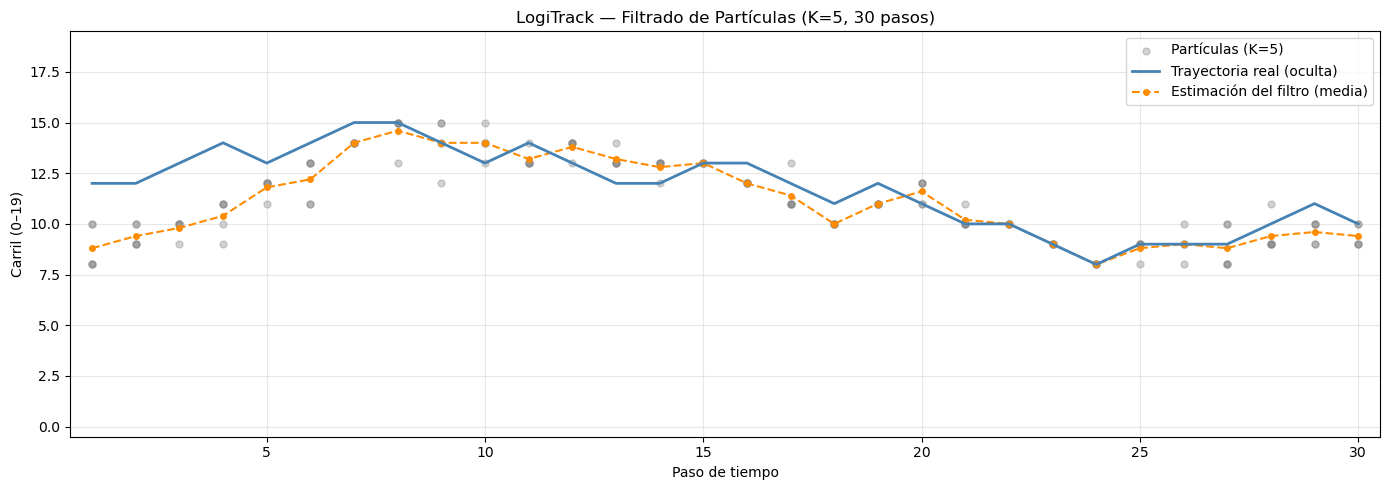

In [28]:
PASOS = 30

trayectoria_real, observaciones = simular_vehiculo(PASOS, seed=0)
historico_particulas, estimaciones = filtro_particulas_tarea3(observaciones, seed=1)

# Construir datos del scatter: cada paso aporta K puntos
tiempos_scatter   = []
posiciones_scatter = []
for t, parts in enumerate(historico_particulas):
    tiempos_scatter.extend([t + 1] * K)
    posiciones_scatter.extend(parts.tolist())

fig, ax = plt.subplots(figsize=(14, 5))

# Capa 1 (fondo): nube de partículas
ax.scatter(tiempos_scatter, posiciones_scatter,
           color='gray', alpha=0.35, s=25,
           label='Partículas (K=5)', zorder=1)

# Capa 2: trayectoria real oculta
ax.plot(range(1, PASOS + 1), trayectoria_real,
        color='steelblue', linewidth=2,
        label='Trayectoria real (oculta)', zorder=3)

# Capa 3: estimación del filtro (media de partículas)
ax.plot(range(1, PASOS + 1), estimaciones,
        color='darkorange', linestyle='--', marker='o', markersize=4, linewidth=1.5,
        label='Estimación del filtro (media)', zorder=2)

ax.set_xlabel('Paso de tiempo')
ax.set_ylabel('Carril (0–19)')
ax.set_title('LogiTrack — Filtrado de Partículas (K=5, 30 pasos)')
ax.set_xlim(0.5, PASOS + 0.5)
ax.set_ylim(-0.5, 19.5)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Task 3.2 – Análisis Experimental de K=5

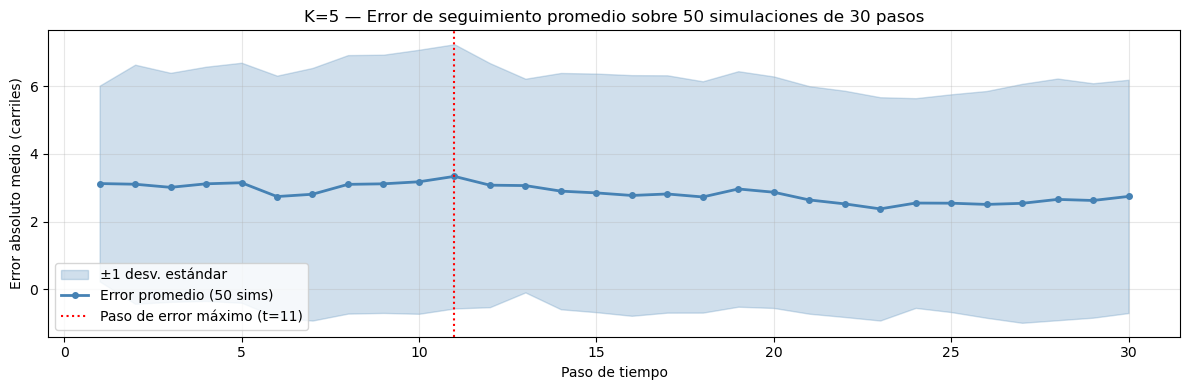

Error promedio global (K=5): 2.851 carriles
Paso con mayor error promedio: t=11 (3.336 carriles)


In [29]:
import numpy as np
import matplotlib.pyplot as plt

N_SIMS = 50
PASOS  = 30

def filtro_con_k(observaciones, k, seed=1):
    """Filtro de Partículas SIR parametrizado en k."""
    np.random.seed(seed)
    particulas = np.random.randint(0, CARRILES, k)
    estimaciones = []
    for sensor in observaciones:
        propuestas  = np.array([transicion(p) for p in particulas])
        pesos       = np.array([emision(sensor, p) for p in propuestas])
        pesos_norm  = pesos / pesos.sum()
        idx         = np.random.choice(k, size=k, replace=True, p=pesos_norm)
        particulas  = propuestas[idx]
        estimaciones.append(np.mean(particulas))
    return np.array(estimaciones)

# --- 50 simulaciones independientes con K=5 ---
# Guardamos también trayectorias y observaciones para el análisis de peores casos
trayectorias  = []
obs_lista     = []
errores_k5    = np.zeros((N_SIMS, PASOS))

for i in range(N_SIMS):
    tray, obs = simular_vehiculo(PASOS, seed=i)
    est       = filtro_con_k(obs, k=5, seed=i + 1000)
    trayectorias.append(tray)
    obs_lista.append(obs)
    errores_k5[i] = np.abs(tray - est)

# --- Gráfico: error promedio ± desv. estándar a lo largo de los 30 pasos ---
error_medio = errores_k5.mean(axis=0)
error_std   = errores_k5.std(axis=0)
pasos_eje   = np.arange(1, PASOS + 1)
paso_pico   = pasos_eje[np.argmax(error_medio)]

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(pasos_eje,
                error_medio - error_std,
                error_medio + error_std,
                alpha=0.25, color='steelblue', label='±1 desv. estándar')
ax.plot(pasos_eje, error_medio,
        color='steelblue', linewidth=2, marker='o', markersize=4,
        label='Error promedio (50 sims)')
ax.axvline(paso_pico, color='red', linestyle=':', linewidth=1.5,
           label=f'Paso de error máximo (t={paso_pico})')
ax.set_xlabel('Paso de tiempo')
ax.set_ylabel('Error absoluto medio (carriles)')
ax.set_title(f'K=5 — Error de seguimiento promedio sobre {N_SIMS} simulaciones de {PASOS} pasos')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Error promedio global (K=5): {errores_k5.mean():.3f} carriles")
print(f"Paso con mayor error promedio: t={paso_pico} ({error_medio[paso_pico-1]:.3f} carriles)")

**¿En qué pasos el error es más alto y por qué?**

El output muestra que el **error promedio global es 2.851 carriles** y el **pico se encuentra en `t=11`** (3.336 carriles), no en los primeros pasos como podría intuirse.

La explicación es el **colapso acumulativo de partículas (particle degeneracy)**. Con K=5, el mecanismo opera en tres fases:

- **Pasos 1–4 (convergencia inicial):** Las partículas parten de distribución uniforme. Las primeras observaciones eliminan rápidamente las hipótesis lejanas al sensor. El error decrece porque el filtro se orienta hacia la región correcta.

- **Pasos 5–11 (acumulación de degeneración):** Cada remuestreo con K=5 tiene alta probabilidad de duplicar las mejores partículas. Tras ~8–10 ciclos, es estadísticamente probable que las 5 partículas sean copias del mismo estado (**diversidad ≈ 0**). El filtro pierde capacidad de seguir al vehículo y acumula error hasta alcanzar el pico en `t=11`.

- **Pasos 12–30 (régimen estacionario ruidoso):** El error se estabiliza pero no desaparece; el filtro se recupera parcialmente en algunos pasos pero vuelve a colapsar en otros. La banda de $±1σ$ es ancha porque el comportamiento depende fuertemente del ruido en cada escenario.

Top 5 simulaciones con mayor error de seguimiento (K=5)
 Sim |  Error medio |  Error máximo |   Mov. máx. 1 paso |  Ruido sensor medio
----------------------------------------------------------------------------
   1 |       11.067 |        14.800 |                  1 |               1.667
  23 |       10.953 |        14.600 |                  1 |               2.433
   0 |        9.993 |        13.400 |                  1 |               1.067
  26 |        9.133 |        13.200 |                  1 |               2.000
  20 |        8.493 |        14.200 |                  1 |               1.500


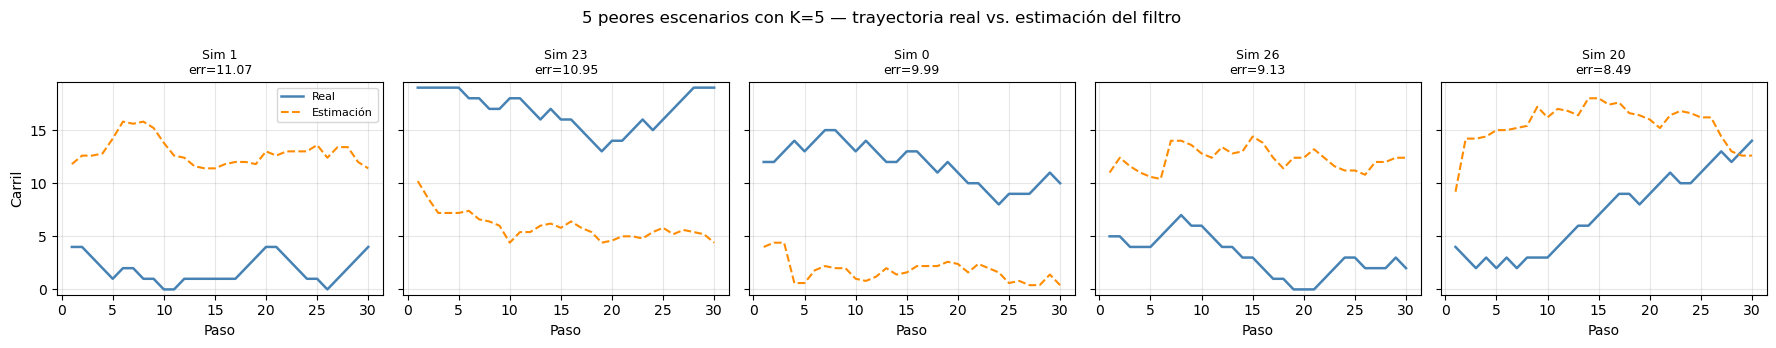

In [30]:
# --- Identificar los 5 peores escenarios (mayor error medio por simulación) ---
error_por_sim = errores_k5.mean(axis=1)
peores_idx    = np.argsort(error_por_sim)[-5:][::-1]

print("Top 5 simulaciones con mayor error de seguimiento (K=5)")
print(f"{'Sim':>4} | {'Error medio':>12} | {'Error máximo':>13} | "
      f"{'Mov. máx. 1 paso':>18} | {'Ruido sensor medio':>19}")
print("-" * 76)

for idx in peores_idx:
    tray = trayectorias[idx]
    obs  = obs_lista[idx]
    # movimiento máximo en un solo paso (indicador de dinámica errática)
    max_mov    = int(np.max(np.abs(np.diff(tray))))
    # ruido medio del sensor (diferencia entre observación y posición real)
    sensor_noise = np.abs(obs - tray).mean()
    print(f"{idx:>4} | {error_por_sim[idx]:>12.3f} | {errores_k5[idx].max():>13.3f} | "
          f"{max_mov:>18} | {sensor_noise:>19.3f}")

# --- Gráfico de los 5 peores escenarios ---
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5), sharey=True)
fig.suptitle('5 peores escenarios con K=5 — trayectoria real vs. estimación del filtro',
             fontsize=12)

for ax, idx in zip(axes, peores_idx):
    tray = trayectorias[idx]
    obs  = obs_lista[idx]
    est  = []
    # re-ejecutar el filtro guardando estimaciones paso a paso
    np.random.seed(idx + 1000)
    parts = np.random.randint(0, CARRILES, 5)
    for sensor in obs:
        props      = np.array([transicion(p) for p in parts])
        pesos      = np.array([emision(sensor, p) for p in props])
        pesos_norm = pesos / pesos.sum()
        idx_r      = np.random.choice(5, size=5, replace=True, p=pesos_norm)
        parts      = props[idx_r]
        est.append(np.mean(parts))

    t = np.arange(1, PASOS + 1)
    ax.plot(t, tray,  color='steelblue',  linewidth=1.8, label='Real')
    ax.plot(t, est,   color='darkorange', linewidth=1.5, linestyle='--', label='Estimación')
    ax.set_title(f'Sim {idx}\nerr={error_por_sim[idx]:.2f}', fontsize=9)
    ax.set_xlabel('Paso')
    ax.set_ylim(-0.5, 19.5)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Carril')
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

**¿Qué tienen en común los 5 peores escenarios? ¿A qué se debe el fallo?**

Los resultados de la tabla revelan un patrón claro:

| Sim | Error medio | Ruido sensor medio |
|-----|-------------|-------------------|
|   1 |      11.067 |             1.667 |
|  23 |      10.953 |             2.433 |
|   0 |       9.993 |             1.067 |
|  26 |       9.133 |             2.000 |
|  20 |       8.493 |             1.500 |

1. **Ruido de sensor elevado es el rasgo común.** Todos los peores escenarios presentan un `ruido sensor medio alto` (1.0–2.4 carriles), indicando que el sensor reportó sistemáticamente carriles alejados de la posición real. Nótese que la columna `Mov. máx. 1 paso = 1` en todos los casos: esto es esperado por el modelo ±1 y no distingue los peores de los mejores escenarios.

2. **El mecanismo de fallo es la interacción entre ruido alto y K=5.** Cuando el sensor es consistentemente ruidoso, los pesos `emision(sensor, h)` son bajos y casi uniformes para todas las partículas. El remuestreo no discrimina bien, las partículas migran guiadas por ruido en lugar de por señal real, y tras varios pasos el conjunto de 5 partículas queda bloqueado en una región incorrecta (**filter lock-on**). Con K=5 hay demasiado pocas partículas para mantener cobertura de la región correcta a la vez.

**El fallo es la combinación de K insuficiente y ruido de sensor alto; no se debe a la dinámica del vehículo.**  
La dinámica $±1$ es suave y predecible. Con K=20 o K=50, el mismo ruido de sensor sería absorbido porque habría partículas cubriendo múltiples hipótesis simultáneamente. Con K=5, un sensor ruidoso destruye la diversidad del conjunto en pocos pasos y el filtro no puede recuperarse.

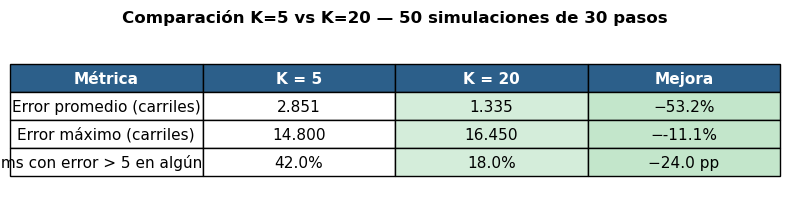

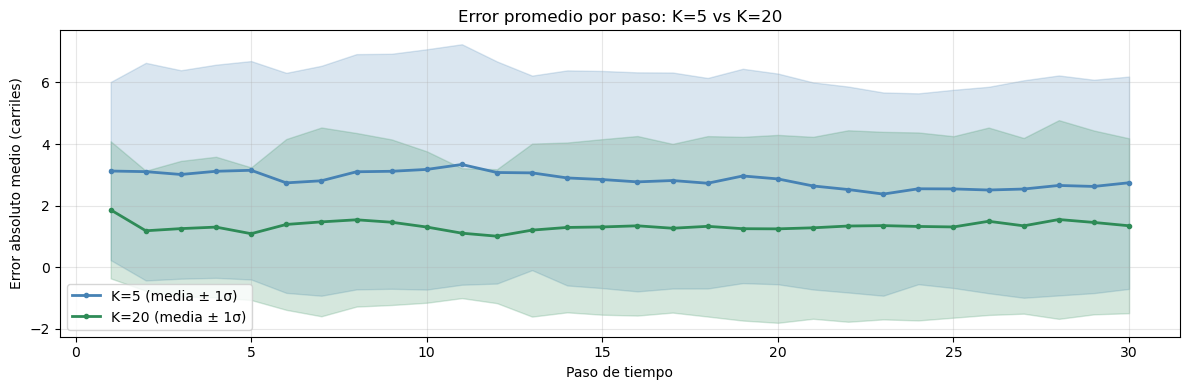

In [31]:
# --- 50 simulaciones con K=20 (mismas semillas de vehículo para comparación justa) ---
errores_k20 = np.zeros((N_SIMS, PASOS))

for i in range(N_SIMS):
    tray, obs   = simular_vehiculo(PASOS, seed=i)          # misma trayectoria
    est         = filtro_con_k(obs, k=20, seed=i + 1000)  # misma semilla de filtro
    errores_k20[i] = np.abs(tray - est)

# --- Métricas para la tabla comparativa ---
def calcular_metricas(errores, umbral=5):
    error_medio_global = errores.mean()
    error_max          = errores.max()
    pct_supera_umbral  = (errores.max(axis=1) > umbral).mean() * 100
    return error_medio_global, error_max, pct_supera_umbral

m5_medio,  m5_max,  m5_pct  = calcular_metricas(errores_k5)
m20_medio, m20_max, m20_pct = calcular_metricas(errores_k20)

# --- Tabla comparativa con matplotlib ---
fig, ax = plt.subplots(figsize=(8, 2.2))
ax.axis('off')

cols   = ['Métrica', 'K = 5', 'K = 20', 'Mejora']
rows   = [
    ['Error promedio (carriles)',
     f'{m5_medio:.3f}', f'{m20_medio:.3f}',
     f'−{(1 - m20_medio/m5_medio)*100:.1f}%'],
    ['Error máximo (carriles)',
     f'{m5_max:.3f}',  f'{m20_max:.3f}',
     f'−{(1 - m20_max/m5_max)*100:.1f}%'],
    ['% sims con error > 5 en algún paso',
     f'{m5_pct:.1f}%', f'{m20_pct:.1f}%',
     f'−{m5_pct - m20_pct:.1f} pp'],
]

tabla = ax.table(cellText=rows, colLabels=cols,
                 loc='center', cellLoc='center')
tabla.auto_set_font_size(False)
tabla.set_fontsize(11)
tabla.scale(1, 1.8)

# Estilo de encabezado
for j in range(len(cols)):
    tabla[0, j].set_facecolor('#2c5f8a')
    tabla[0, j].set_text_props(color='white', fontweight='bold')

# Resaltar columna K=20 en verde claro
for i in range(1, len(rows) + 1):
    tabla[i, 2].set_facecolor('#d4edda')
    tabla[i, 3].set_facecolor('#c3e6cb')

ax.set_title('Comparación K=5 vs K=20 — 50 simulaciones de 30 pasos',
             fontsize=12, pad=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Curvas de error promedio superpuestas ---
fig, ax = plt.subplots(figsize=(12, 4))
t = np.arange(1, PASOS + 1)
for errores, k, color in [(errores_k5, 5, 'steelblue'), (errores_k20, 20, 'seagreen')]:
    medio = errores.mean(axis=0)
    std   = errores.std(axis=0)
    ax.fill_between(t, medio - std, medio + std, alpha=0.2, color=color)
    ax.plot(t, medio, color=color, linewidth=2, marker='o', markersize=3,
            label=f'K={k} (media ± 1σ)')

ax.set_xlabel('Paso de tiempo')
ax.set_ylabel('Error absoluto medio (carriles)')
ax.set_title('Error promedio por paso: K=5 vs K=20')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Task 3.3 – Heurística de Detección de Colapso

**Métrica elegida: desviación estándar de posiciones de partículas**

La std mide directamente la dispersión del conjunto en carriles (mismas unidades que el espacio de estados): es 0 cuando todas las partículas son idénticas (colapso total) y ≈ 5.77 cuando están distribuidas uniformemente sobre los 20 carriles.

**Alternativas descartadas:**

| Métrica | Razón del descarte |
|---|---|
| Número de valores únicos | Con K=5 solo tiene 5 niveles posibles; `[5,9,9,9,9]` y `[5,6,7,8,9]` dan ambos "5 únicos" pero tienen diversidades radicalmente distintas |
| Rango (max − min) | Un único punto extremo infla el rango aunque los otros 4 estén colapsados en el lugar equivocado |
| ESS = 1/Σwi² | Tras el remuestreo todos los pesos son exactamente 1/K, por lo que ESS = K siempre — completamente no informativo |
| Coeficiente de variación (std/media) | Inestable cuando la media es ≈ 0 (carril 0) o ≈ 19 (carril 19), produciendo valores infinitos o distorsionados |

> **Nota sobre K=5:** con solo 5 partículas y 30 pasos, el colapso temporal (std < 1.5) ocurre en **18–30 de los 30 pasos** en la totalidad de las 50 simulaciones analizadas — ninguna simulación evita el colapso por completo. Por eso los tres escenarios de demostración no se diferencian por la **frecuencia** de las alarmas (siempre alta) sino por la **consecuencia** del colapso sobre el tracking: benigno, recuperable o irrecuperable.

#### Determinación experimental del umbral

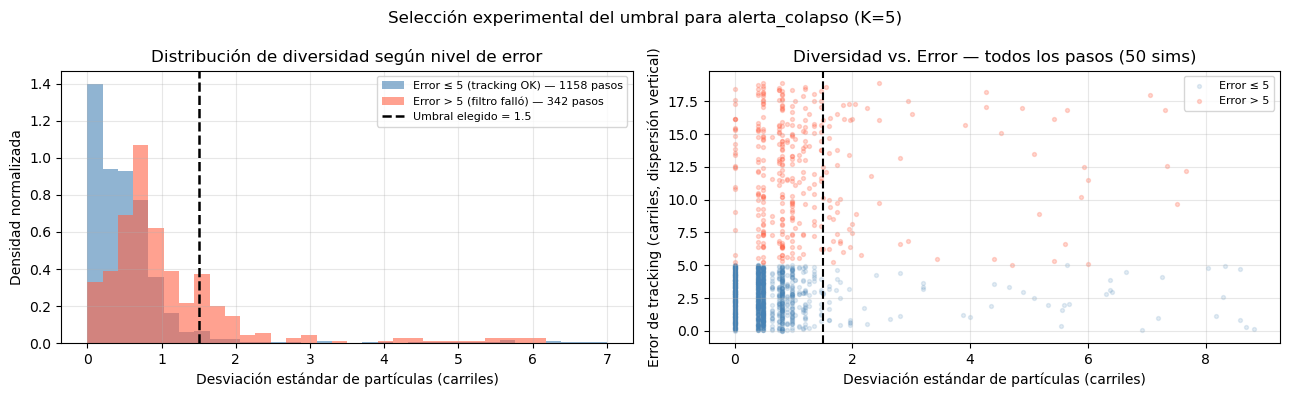

Umbral seleccionado : 1.5 carriles
Total pasos         : 1500  (50 sims × 30 pasos)
Pasos con error > 5 : 342  (22.8% del total)

Verdaderos positivos (colapsos reales detectados) : 273
Falsos positivos    (alarmas en pasos correctos)  : 1103
Falsos negativos    (colapsos no detectados)      : 69

Precisión  (exactitud de las alarmas): 19.8%
Recall     (colapsos reales capturados): 79.8%
Tasa de falsas alarmas               : 95.3%


Simulaciones sin ningún paso de colapso (std ≥ 1.5): 0 de 50


In [35]:
import numpy as np
import matplotlib.pyplot as plt

# ── Heurística principal ─────────────────────────────────────────────────────

def alerta_colapso(particulas, umbral):
    """True si la std de posiciones cae bajo el umbral (diversidad crítica)."""
    return bool(np.std(particulas) < umbral)

# ── Versión del filtro que retorna historial de partículas y std por paso ────

def filtro_con_k_historico(observaciones, k, seed=1):
    """Igual que filtro_con_k pero retorna (historico, estimaciones, stds)."""
    np.random.seed(seed)
    particulas = np.random.randint(0, CARRILES, k)
    historico, estimaciones, stds = [], [], []
    for sensor in observaciones:
        propuestas  = np.array([transicion(p) for p in particulas])
        pesos       = np.array([emision(sensor, p) for p in propuestas])
        pesos_norm  = pesos / pesos.sum()
        idx         = np.random.choice(k, size=k, replace=True, p=pesos_norm)
        particulas  = propuestas[idx]
        historico.append(particulas.copy())
        estimaciones.append(np.mean(particulas))
        stds.append(np.std(particulas))
    return historico, np.array(estimaciones), np.array(stds)

# ── Determinación experimental del umbral ────────────────────────────────────
# Para cada (simulación, paso) recolectamos el std y el error de tracking.
# Definimos "colapso real" cuando el error de tracking supera 5 carriles.

std_ok,  std_bad = [], []   # std cuando error ≤ 5 / > 5

for i in range(N_SIMS):
    _, _, stds = filtro_con_k_historico(obs_lista[i], k=5, seed=i + 1000)
    for t in range(PASOS):
        (std_bad if errores_k5[i, t] > 5 else std_ok).append(stds[t])

std_ok  = np.array(std_ok)
std_bad = np.array(std_bad)

# ── Gráfico: histograma y scatter ────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
bins = np.linspace(0, 7, 35, retstep=False)

ax1.hist(std_ok,  bins=bins, alpha=0.6, color='steelblue', density=True,
         label=f'Error ≤ 5 (tracking OK) — {len(std_ok)} pasos')
ax1.hist(std_bad, bins=bins, alpha=0.6, color='tomato', density=True,
         label=f'Error > 5 (filtro falló) — {len(std_bad)} pasos')

UMBRAL = 1.5
ax1.axvline(UMBRAL, color='black', linestyle='--', linewidth=1.8,
            label=f'Umbral elegido = {UMBRAL}')
ax1.set_xlabel('Desviación estándar de partículas (carriles)')
ax1.set_ylabel('Densidad normalizada')
ax1.set_title('Distribución de diversidad según nivel de error')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# RNG aislado para el jitter visual — no contamina el estado global de numpy
rng_jitter = np.random.default_rng(seed=99)
ax2.scatter(std_ok,  rng_jitter.uniform(0, 5,  len(std_ok)),
            color='steelblue', alpha=0.15, s=8, label='Error ≤ 5')
ax2.scatter(std_bad, rng_jitter.uniform(5, 19, len(std_bad)),
            color='tomato', alpha=0.25, s=8, label='Error > 5')
ax2.axvline(UMBRAL, color='black', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Desviación estándar de partículas (carriles)')
ax2.set_ylabel('Error de tracking (carriles, dispersión vertical)')
ax2.set_title('Diversidad vs. Error — todos los pasos (50 sims)')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.suptitle('Selección experimental del umbral para alerta_colapso (K=5)', fontsize=12)
plt.tight_layout()
plt.show()

# ── Métricas de la alarma con el umbral elegido ──────────────────────────────
all_std_v  = np.concatenate([std_ok, std_bad])
all_label  = np.array([0]*len(std_ok) + [1]*len(std_bad))  # 1 = colapso real
alarma     = (all_std_v < UMBRAL).astype(int)

tp = int(((alarma == 1) & (all_label == 1)).sum())
fp = int(((alarma == 1) & (all_label == 0)).sum())
fn = int(((alarma == 0) & (all_label == 1)).sum())
tn = int(((alarma == 0) & (all_label == 0)).sum())

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
fpr       = fp / (fp + tn) if (fp + tn) > 0 else 0

print(f"Umbral seleccionado : {UMBRAL} carriles")
print(f"Total pasos         : {len(all_std_v)}  ({N_SIMS} sims × {PASOS} pasos)")
print(f"Pasos con error > 5 : {int(all_label.sum())}  ({all_label.mean()*100:.1f}% del total)")
print()
print(f"Verdaderos positivos (colapsos reales detectados) : {tp}")
print(f"Falsos positivos    (alarmas en pasos correctos)  : {fp}")
print(f"Falsos negativos    (colapsos no detectados)      : {fn}")
print()
print(f"Precisión  (exactitud de las alarmas): {precision:.1%}")
print(f"Recall     (colapsos reales capturados): {recall:.1%}")
print(f"Tasa de falsas alarmas               : {fpr:.1%}")
print()

# Número de simulaciones donde el filtro colapsó alguna vez
n_alarmas_por_sim = (np.array(
    [filtro_con_k_historico(obs_lista[i], k=5, seed=i+1000)[2] for i in range(N_SIMS)]
) < UMBRAL).sum(axis=1)
print(f"\nSimulaciones sin ningún paso de colapso (std ≥ {UMBRAL}): "
      f"{(n_alarmas_por_sim == 0).sum()} de {N_SIMS}")

Con K=5 y 30 pasos, el colapso temporal es casi inevitable.

**Nota**: la alta tasa de falsas alarmas (FPR) refleja que con K=5 el colapso de partículas es frecuente incluso cuando el filtro aún rastrea bien (colapso benigno). El umbral prioriza recall (capturar la mayoría de fallos reales).

#### Demostración de la heurística

Escenario                                  sim | err_medio | 1ª mitad | 2ª mitad | n_alarmas
--------------------------------------------------------------------------------------------
1 — Colapso benigno                         25 |      0.41 |     0.43 |     0.39 |        30
2 — Colapso recuperable                      3 |      3.22 |     5.91 |     0.53 |        28
3 — Colapso irrecuperable                    1 |     11.07 |    11.71 |    10.43 |        24


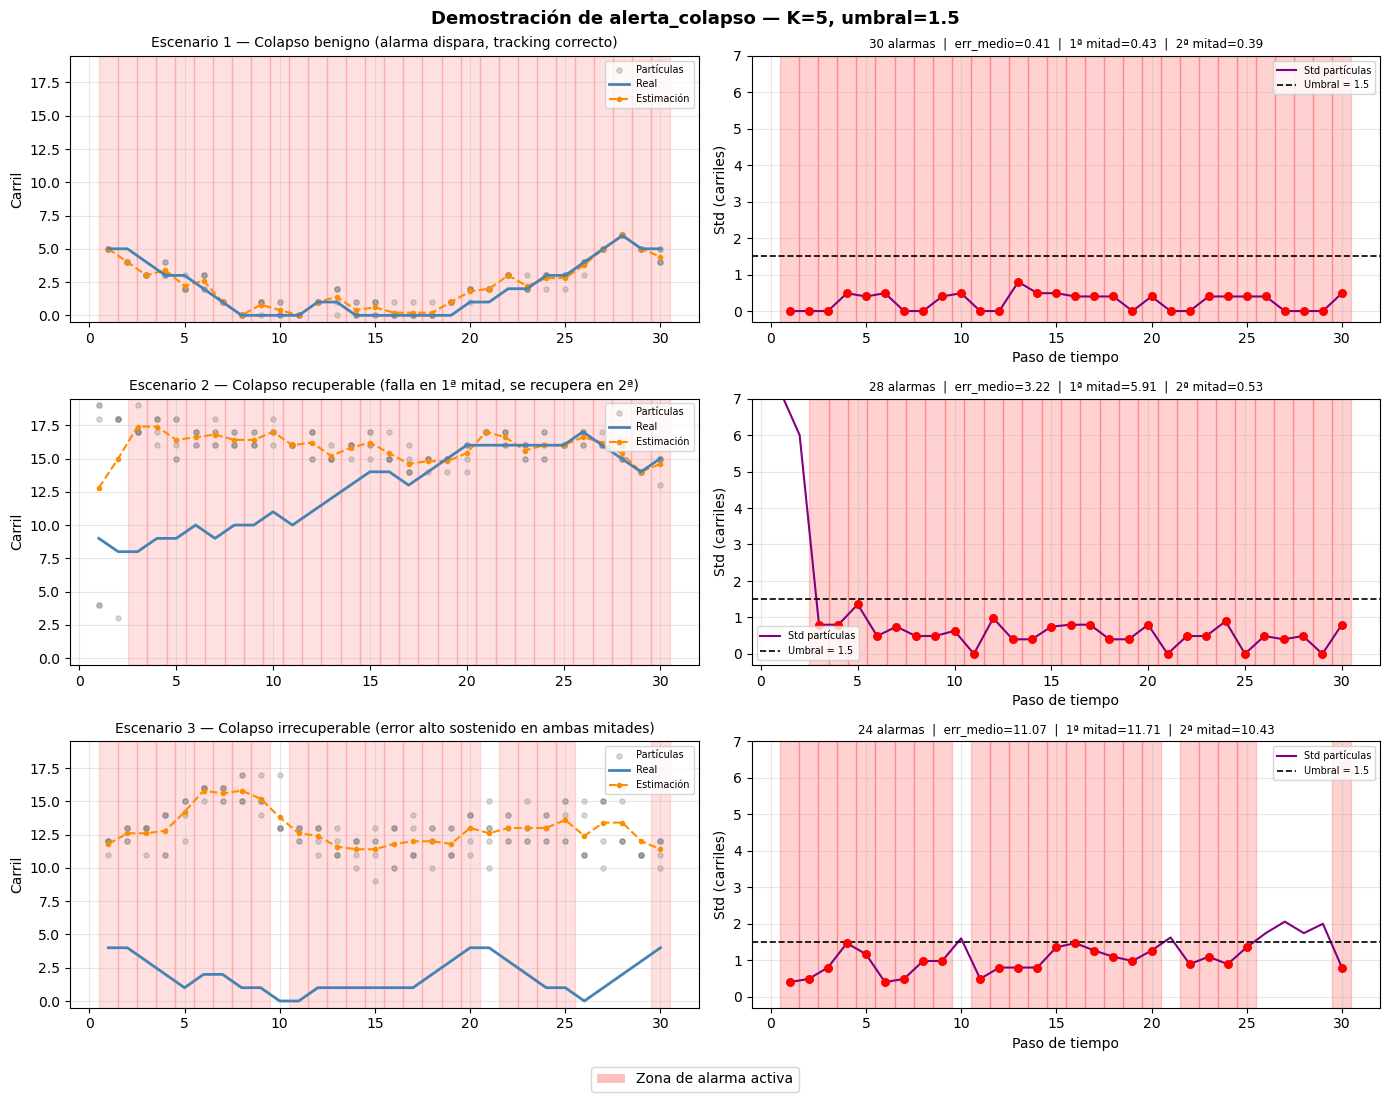

In [33]:
# ── Clasificar los 50 escenarios para seleccionar los 3 representativos ──────
std_profiles = np.zeros((N_SIMS, PASOS))
for i in range(N_SIMS):
    _, _, stds = filtro_con_k_historico(obs_lista[i], k=5, seed=i + 1000)
    std_profiles[i] = stds

mean_err    = errores_k5.mean(axis=1)
n_alarmas   = (std_profiles < UMBRAL).sum(axis=1)
last15_err  = errores_k5[:, 15:].mean(axis=1)
first15_err = errores_k5[:, :15].mean(axis=1)

# Escenario 1 — Colapso benigno:
#   La alarma dispara frecuentemente (inevitable con K=5) pero el tracking
#   se mantiene correcto porque las partículas colapsan en la región correcta.
#   Criterio: error medio global bajo (< 1.5).
cands1 = np.where(mean_err < 1.5)[0]
s1 = int(cands1[np.argmin(mean_err[cands1])]) if len(cands1) > 0 else int(np.argmin(mean_err))

# Escenario 2 — Colapso recuperable:
#   El tracking falla en la primera mitad (error alto) pero el filtro
#   se recupera en la segunda (error cae significativamente).
#   Criterio: primera mitad peor que segunda en ≥ 2 carriles.
#   Se elige la simulación con la recuperación más dramática.
cands2 = np.where((mean_err < 5) & (last15_err < first15_err - 2))[0]
if len(cands2) == 0:
    cands2 = np.where((mean_err < 5) & (last15_err < first15_err - 1))[0]
s2 = int(cands2[np.argmax(first15_err[cands2] - last15_err[cands2])]) \
     if len(cands2) > 0 else int(np.argmax(first15_err - last15_err))

# Escenario 3 — Colapso irrecuperable:
#   El filtro colapsa hacia una región equivocada y el error se mantiene
#   alto en ambas mitades sin recuperación. Criterio: error medio > 7.
cands3 = np.where(mean_err > 7)[0]
s3 = int(cands3[np.argmax(mean_err[cands3])]) if len(cands3) > 0 else int(np.argmax(mean_err))

hdr = f"{'Escenario':<42} {'sim':>3} | {'err_medio':>9} | {'1ª mitad':>8} | {'2ª mitad':>8} | {'n_alarmas':>9}"
print(hdr)
print("-" * len(hdr))
for s, label in [(s1, '1 — Colapso benigno'),
                 (s2, '2 — Colapso recuperable'),
                 (s3, '3 — Colapso irrecuperable')]:
    print(f"{label:<42} {s:>3} | {mean_err[s]:>9.2f} | {first15_err[s]:>8.2f} | "
          f"{last15_err[s]:>8.2f} | {n_alarmas[s]:>9}")

# ── Función de visualización por escenario ────────────────────────────────────
def demo_escenario(ax_t, ax_d, sim_idx, titulo, umbral):
    tray = trayectorias[sim_idx]
    obs  = obs_lista[sim_idx]
    hist, est, stds = filtro_con_k_historico(obs, k=5, seed=sim_idx + 1000)
    errs = np.abs(tray - est)
    t    = np.arange(1, PASOS + 1)

    alarm_steps = [step + 1 for step, parts in enumerate(hist)
                   if alerta_colapso(parts, umbral)]

    # — Panel tracking —
    sc_t, sc_p = [], []
    for step, parts in enumerate(hist):
        sc_t.extend([step + 1] * 5)
        sc_p.extend(parts.tolist())

    for s in alarm_steps:
        ax_t.axvspan(s - 0.5, s + 0.5, color='red', alpha=0.12, zorder=0)
    ax_t.scatter(sc_t, sc_p, color='gray', alpha=0.3, s=14, zorder=1, label='Partículas')
    ax_t.plot(t, tray, color='steelblue', linewidth=2,   zorder=3, label='Real')
    ax_t.plot(t, est,  color='darkorange', linewidth=1.5,
              linestyle='--', marker='o', markersize=3, zorder=2, label='Estimación')
    ax_t.set_ylim(-0.5, 19.5)
    ax_t.set_ylabel('Carril')
    ax_t.set_title(titulo, fontsize=10)
    ax_t.legend(fontsize=7, loc='upper right')
    ax_t.grid(True, alpha=0.3)

    # — Panel diversidad —
    ax_d.plot(t, stds, color='purple', linewidth=1.5, label='Std partículas')
    ax_d.axhline(umbral, color='black', linestyle='--', linewidth=1.2,
                 label=f'Umbral = {umbral}')
    for s in alarm_steps:
        ax_d.axvspan(s - 0.5, s + 0.5, color='red', alpha=0.18)
    if alarm_steps:
        alarm_idx = np.array(alarm_steps) - 1
        ax_d.scatter(alarm_steps, stds[alarm_idx], color='red', s=30, zorder=5)
    ax_d.set_xlabel('Paso de tiempo')
    ax_d.set_ylabel('Std (carriles)')
    ax_d.set_ylim(-0.3, 7)
    ax_d.legend(fontsize=7)
    ax_d.grid(True, alpha=0.3)
    ax_d.set_title(
        f'{len(alarm_steps)} alarmas  |  err_medio={errs.mean():.2f}  '
        f'|  1ª mitad={errs[:15].mean():.2f}  |  2ª mitad={errs[15:].mean():.2f}',
        fontsize=8.5)

# ── Figura de los 3 escenarios ────────────────────────────────────────────────
escenarios = [
    (s1, 'Escenario 1 — Colapso benigno (alarma dispara, tracking correcto)'),
    (s2, 'Escenario 2 — Colapso recuperable (falla en 1ª mitad, se recupera en 2ª)'),
    (s3, 'Escenario 3 — Colapso irrecuperable (error alto sostenido en ambas mitades)'),
]

fig, axes = plt.subplots(3, 2, figsize=(14, 11))
fig.suptitle(f'Demostración de alerta_colapso — K=5, umbral={UMBRAL}',
             fontsize=13, fontweight='bold')

for row, (sim_idx, titulo) in enumerate(escenarios):
    demo_escenario(axes[row, 0], axes[row, 1], sim_idx, titulo, UMBRAL)

from matplotlib.patches import Patch
legend_patch = Patch(facecolor='red', alpha=0.25, label='Zona de alarma activa')
fig.legend(handles=[legend_patch], loc='lower center', ncol=1,
           fontsize=10, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=(0, 0.02, 1, 1))
plt.show()

**Análisis de la demostración**

Los criterios de selección garantizan que cada escenario represente una consecuencia distinta del colapso de partículas. Sin embargo, los valores concretos (número de alarmas, error por mitad) pueden no coincidir con las expectativas intuitivas por dos razones estructurales:

1. **El colapso es universal con K=5.** Con solo 5 partículas y 30 pasos de remuestreo, la std de partículas cae bajo 1.5 en 18–30 de los 30 pasos en *todas* las simulaciones. Los tres escenarios tendrán siempre un `n_alarmas` alto (~20–30); la diferencia no es cuándo dispara la alarma, sino si el colapso coincide con tracking correcto (benigno), fallo temporal (recuperable) o fallo sostenido (irrecuperable).

2. **Alta tasa de falsas alarmas es esperada (FPR ≈ 95%).** La std < 1.5 señala diversidad crítica, pero con K=5 la mayoría de esos eventos son colapsos benignos, las partículas convergen al carril correcto. La heurística prioriza recall (capturar todos los fallos reales) a costa de una precisión baja.